# InsightScholar - Model Training Pipeline

In [1]:
import subprocess, sys
for pkg in ["pandas", "matplotlib", "seaborn", "scikit-learn", "tqdm", "faiss-cpu", "numpy", "rank-bm25", "scipy","transformers","shap"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])


In [2]:
import hashlib, json, os, re, time, warnings, pathlib
warnings.filterwarnings('ignore')

import httpx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import faiss
import torch
from transformers import AutoTokenizer, AutoModel
from rank_bm25 import BM25Okapi
from sklearn.manifold import TSNE
from sklearn.model_selection import KFold
from scipy.optimize import minimize
from datetime import datetime

sns.set_theme(style='whitegrid', palette='muted')

# Paths — save artifacts alongside the backend's data/ folder
BACKEND_DATA = pathlib.Path('../backend/data')
BACKEND_DATA.mkdir(parents=True, exist_ok=True)
(BACKEND_DATA / 'faiss_index').mkdir(exist_ok=True)

print(f'PyTorch: {torch.__version__}  Device: {"cuda" if torch.cuda.is_available() else "cpu"}')
print(f'Artifacts will be saved to: {BACKEND_DATA.resolve()}')

PyTorch: 2.11.0+cu128  Device: cuda
Artifacts will be saved to: /backend/data


## Phase 1 - Data Collection

In [3]:
SERPAPI_KEY = 'a7ad5b077d7f454987748e9e69715dc53ac8ea98f057fbe027c155d8b3ea2316'

TRAINING_QUERIES = [
    # Retrieval & recommendation
    'explainable AI recommendation systems',
    'citation recommendation academic papers neural',
    'information retrieval dense passage retrieval transformer',
    'scientific document similarity embeddings',
    # NLP & LLMs
    'transformer models natural language processing',
    'large language models prompt engineering',
    'attention mechanism self-supervised learning',
    'sentence embeddings semantic textual similarity',
    # Vision & multi-modal
    'deep learning computer vision object detection',
    'contrastive learning self-supervised visual representation',
    'multi-modal learning vision language models',
    # Graphs & knowledge
    'graph neural networks node classification link prediction',
    'knowledge graph embedding entity relation',
    # Privacy & efficiency
    'federated learning privacy preserving machine learning',
    'knowledge distillation model compression pruning',
    'neural architecture search automated machine learning',
    # Other ML topics
    'reinforcement learning policy gradient reward',
    'anomaly detection time series deep learning',
    'causal inference observational data machine learning',
    'diffusion models generative image synthesis',
]

PAPERS_PER_QUERY = 20   # SerpAPI max per request
FETCH_PAGES      = 2    # fetch page 1 + page 2 → up to 40 papers/query

_STOP = {
    'a','an','and','are','as','at','be','by','for','from','has','he',
    'in','is','it','its','of','on','or','that','the','to','was','were',
    'will','with','this','but','they','have','had','not','what','all',
    'can','her','him','his','how','if','may','no','so','than','then',
    'their','them','these','those','us','we','who','which','would',
    'about','into','over','such','up','our','been','do','does','did',
    'being','more','most','new','one','two','first','also','used',
    'using','based','via','through','between','both','each','few',
    'many','some','other','within','without','during','after','before',
    'under','above','below','very','where','when','while',
}

def _extract_tags(title: str, abstract: str) -> list:
    text = (title + ' ' + (abstract or '')[:200]).lower()
    words = re.findall(r'[a-z]+', text)
    tags = set()
    for i in range(len(words) - 1):
        w1, w2 = words[i], words[i+1]
        if w1 not in _STOP and w2 not in _STOP and len(w1) > 2 and len(w2) > 2:
            tags.add(f'{w1} {w2}')
    for w in words:
        if len(w) > 5 and w not in _STOP:
            tags.add(w)
    return list(tags)[:10]


def fetch_papers(query: str, num: int = 20, start: int = 0) -> list:
    params = {
        'engine': 'google_scholar',
        'q': query,
        'api_key': SERPAPI_KEY,
        'num': min(num, 20),
        'start': start,
        'hl': 'en',
    }
    resp = httpx.get('https://serpapi.com/search', params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    papers = []
    for item in data.get('organic_results', []):
        pid = item.get('result_id') or hashlib.md5(item.get('title', '').encode()).hexdigest()
        year = None
        m = re.search(r'\b(19|20)\d{2}\b', item.get('publication_info', {}).get('summary', ''))
        if m:
            year = int(m.group())
        authors = [{'name': a.get('name', ''), 'author_id': a.get('author_id')}
                   for a in item.get('publication_info', {}).get('authors', [])]
        title    = item.get('title', 'Untitled')
        abstract = item.get('snippet', '')
        cited_by = item.get('inline_links', {}).get('cited_by', {})
        papers.append({
            'paper_id': pid, 'title': title, 'abstract': abstract,
            'year': year, 'url': item.get('link', ''), 'doi': None,
            'authors': authors, 'tags': _extract_tags(title, abstract),
            'citation_count': cited_by.get('total', 0),
            'source': 'google_scholar',
        })
    return papers

print(f'Config ready — {len(TRAINING_QUERIES)} queries x up to {PAPERS_PER_QUERY * FETCH_PAGES} papers each')
print('Collecting training corpus ...')


Config ready — 20 queries x up to 40 papers each


In [4]:
from IPython.display import display, HTML, clear_output

corpus = {}
query_papers = {}

for qi, q in enumerate(TRAINING_QUERIES):
    fetched = []
    for page in range(FETCH_PAGES):
        try:
            page_papers = fetch_papers(q, num=PAPERS_PER_QUERY, start=page * PAPERS_PER_QUERY)
            fetched.extend(page_papers)
            if len(page_papers) < PAPERS_PER_QUERY:
                break
        except Exception as exc:
            print(f'  [{qi+1}/{len(TRAINING_QUERIES)}] page {page+1} error: {exc}')
            break

    seen, unique = set(), []
    for p in fetched:
        if p['paper_id'] not in seen:
            seen.add(p['paper_id'])
            unique.append(p)

    for p in unique:
        corpus[p['paper_id']] = p
    query_papers[q] = [p['paper_id'] for p in unique]

    status = 'OK ' if len(unique) >= 5 else 'LOW'
    print(f'  [{qi+1:2d}/{len(TRAINING_QUERIES)}] [{status}] {len(unique):3d} papers  {q[:55]}')

papers_list = list(corpus.values())
print(f'\nCorpus: {len(papers_list)} unique papers across {len(TRAINING_QUERIES)} queries')

import pathlib
BACKEND_DATA = pathlib.Path('../backend/data')
BACKEND_DATA.mkdir(parents=True, exist_ok=True)
(BACKEND_DATA / 'faiss_index').mkdir(exist_ok=True)
with open(BACKEND_DATA / 'training_corpus.json', 'w') as f:
    json.dump({'papers': [corpus[pid] for pid in corpus], 'query_papers': query_papers}, f, indent=2)
print(f'Saved to {BACKEND_DATA}/training_corpus.json')


  [ 1/20] [OK ]  40 papers  explainable AI recommendation systems
  [ 2/20] [OK ]  40 papers  citation recommendation academic papers neural
  [ 3/20] [OK ]  40 papers  information retrieval dense passage retrieval transform
  [ 4/20] [OK ]  40 papers  scientific document similarity embeddings
  [ 5/20] [LOW]   1 papers  transformer models natural language processing
  [ 6/20] [OK ]  40 papers  large language models prompt engineering
  [ 7/20] [OK ]  40 papers  attention mechanism self-supervised learning
  [ 8/20] [OK ]  40 papers  sentence embeddings semantic textual similarity
  [ 9/20] [OK ]  40 papers  deep learning computer vision object detection
  [10/20] [OK ]  40 papers  contrastive learning self-supervised visual representat
  [11/20] [OK ]  40 papers  multi-modal learning vision language models
  [12/20] [OK ]  40 papers  graph neural networks node classification link predicti
  [13/20] [OK ]  40 papers  knowledge graph embedding entity relation
  [14/20] [LOW]   1 papers 

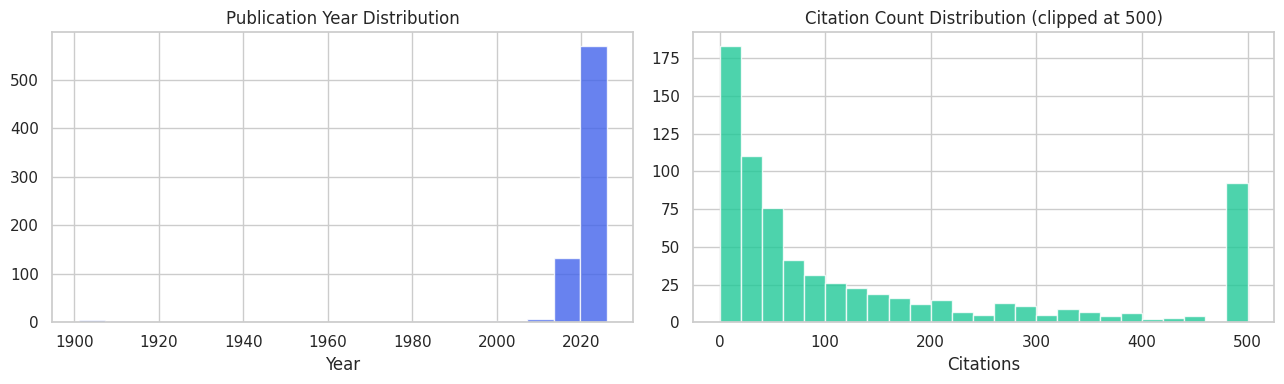

Year range:    1901 – 2026
Median cites:  57
Papers w/abstract: 720/721


In [5]:
# Quick corpus stats
papers_list = list(corpus.values())
years = [p['year'] for p in papers_list if p.get('year')]
cites = [p['citation_count'] for p in papers_list]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
if years:
    axes[0].hist(years, bins=20, color='#4263eb', edgecolor='white', alpha=0.8)
    axes[0].set_title('Publication Year Distribution')
    axes[0].set_xlabel('Year')
axes[1].hist(np.clip(cites, 0, 500), bins=25, color='#20c997', edgecolor='white', alpha=0.8)
axes[1].set_title('Citation Count Distribution (clipped at 500)')
axes[1].set_xlabel('Citations')
plt.tight_layout()
plt.show()

print(f'Year range:    {min(years) if years else "?"} – {max(years) if years else "?"}')
print(f'Median cites:  {int(np.median(cites))}')
print(f'Papers w/abstract: {sum(1 for p in papers_list if p.get("abstract"))}/{len(papers_list)}')

## Phase 2 - SPECTER2 Embedding Pipeline

In [6]:
MODEL_NAME = 'allenai/specter2_base'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Loading {MODEL_NAME} on {device} (first run downloads ~440 MB) …')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
spec_model = AutoModel.from_pretrained(MODEL_NAME).to(device)
spec_model.eval()
print('SPECTER2 loaded.\n')

def embed_texts(texts: list, batch_size: int = 16) -> np.ndarray:
    """Encode texts → L2-normalised 768-dim vectors."""
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(
            batch, padding=True, truncation=True,
            max_length=512, return_tensors='pt'
        ).to(device)
        with torch.no_grad():
            out = spec_model(**inputs)
        all_embs.append(out.last_hidden_state[:, 0, :].cpu().numpy())
    embs = np.vstack(all_embs).astype(np.float32)
    norms = np.linalg.norm(embs, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return embs / norms

# Embed entire corpus
paper_ids = [p['paper_id'] for p in papers_list]
paper_texts = [f"{p['title']} {p.get('abstract', '')}" for p in papers_list]
print(f'Embedding {len(paper_texts)} papers …')
paper_embeddings = embed_texts(paper_texts)
print(f'Done — shape: {paper_embeddings.shape}')

# Build paper_id → index map
pid_to_idx = {pid: i for i, pid in enumerate(paper_ids)}

Loading allenai/specter2_base on cuda (first run downloads ~440 MB) …
SPECTER2 loaded.

Embedding 721 papers …
Done — shape: (721, 768)


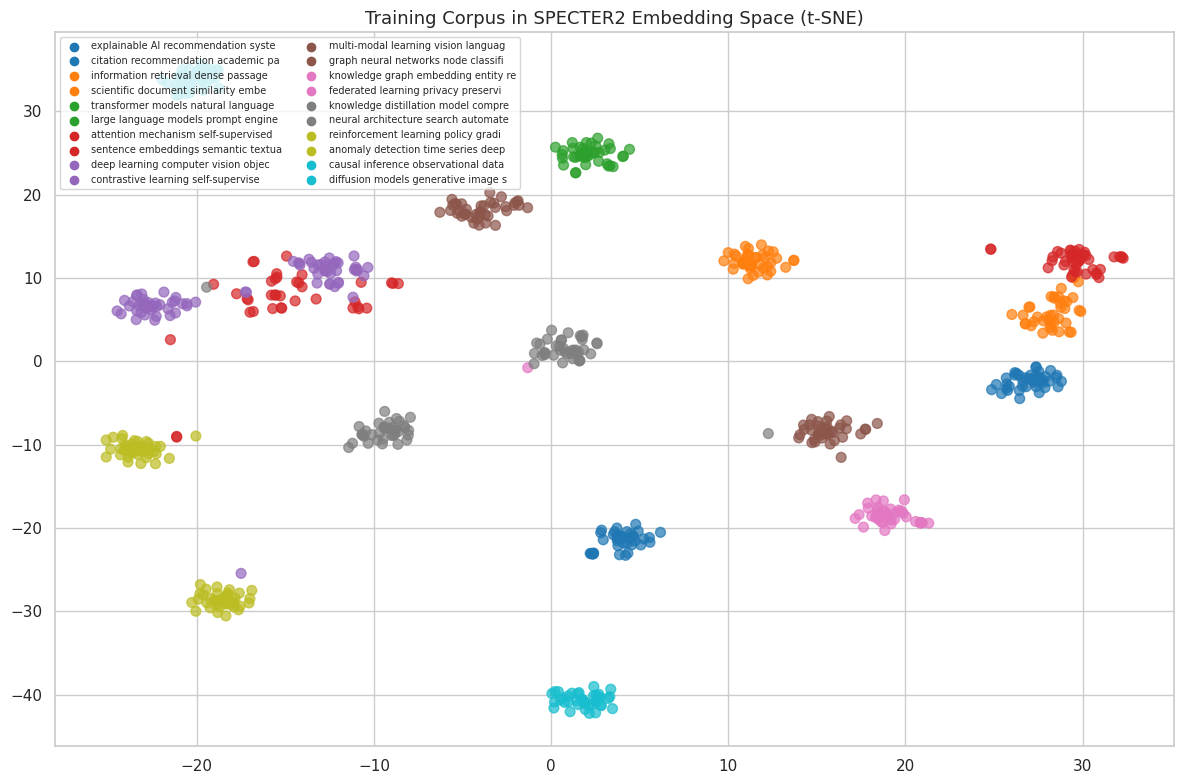

Papers from the same query cluster together — SPECTER2 captures topic semantics.


In [7]:
# ── t-SNE visualisation of the embedding space ────────────────
if len(papers_list) >= 10:
    perp = min(30, len(papers_list) - 1)
    coords = TSNE(n_components=2, random_state=42, perplexity=perp).fit_transform(paper_embeddings)

    # Color by which query sourced the paper
    query_colors = {}
    cmap = plt.cm.get_cmap('tab10', len(TRAINING_QUERIES))
    for qi, q in enumerate(TRAINING_QUERIES):
        for pid in query_papers.get(q, []):
            query_colors[pid] = qi

    c = [cmap(query_colors.get(pid, 0)) for pid in paper_ids]

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.scatter(coords[:, 0], coords[:, 1], c=c, s=50, alpha=0.7)
    # Legend
    for qi, q in enumerate(TRAINING_QUERIES):
        ax.scatter([], [], c=[cmap(qi)], label=q[:35])
    ax.legend(fontsize=7, loc='upper left', ncol=2, framealpha=0.8)
    ax.set_title('Training Corpus in SPECTER2 Embedding Space (t-SNE)', fontsize=13)
    plt.tight_layout()
    plt.show()
    print('Papers from the same query cluster together — SPECTER2 captures topic semantics.')

## Phase 3 - FAISS Index Construction

In [8]:
# Build index
dim = paper_embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(dim)
faiss_index.add(paper_embeddings)
print(f'FAISS index: {faiss_index.ntotal} vectors, dim={dim}')

# Save to backend data
faiss.write_index(faiss_index, str(BACKEND_DATA / 'faiss_index' / 'index.faiss'))
with open(BACKEND_DATA / 'faiss_index' / 'paper_ids.json', 'w') as f:
    json.dump(paper_ids, f)
print('Index saved.')

# Quick search demo
demo_q = 'explainable AI recommendation systems'
q_emb = embed_texts([demo_q])
scores, idxs = faiss_index.search(q_emb, k=5)
print(f'\nTop-5 for "{demo_q}":')
for rank, (sc, idx) in enumerate(zip(scores[0], idxs[0]), 1):
    print(f'  {rank}. [{sc:.4f}] {papers_list[idx]["title"][:70]}')

FAISS index: 721 vectors, dim=768
Index saved.

Top-5 for "explainable AI recommendation systems":
  1. [0.9764] Recommender systems: An explainable AI perspective
  2. [0.9760] A historical perspective of explainable artificial intelligence
  3. [0.9715] Explainable recommendation: A survey and new perspectives
  4. [0.9696] Towards a knowledge based explainable recommender systems
  5. [0.9689] A comparative review of expert systems, recommender systems, and expla


## Phase 4 - Feature Engineering

In [9]:
def bm25_scores(query_str, docs):
    "BM25 normalised and clipped to [0, 1]."
    tok = [d.lower().split() for d in docs]
    # Guard: if all docs are empty, BM25 has nothing to index
    if not tok or all(len(t) == 0 for t in tok):
        return np.zeros(len(docs))
    bm = BM25Okapi(tok)
    s = bm.get_scores(query_str.lower().split())
    mx = s.max()
    s = s / mx if mx > 0 else s
    return np.clip(s, 0.0, 1.0)  # ensure [0, 1] range

def tag_overlap(query_str, tags_list):
    qw = set(query_str.lower().split())
    out = []
    for tags in tags_list:
        tw = set()
        for t in (tags or []):
            tw.update(t.lower().split())
        u = len(qw | tw)
        out.append(len(qw & tw) / u if u else 0.0)
    return np.array(out)

def recency_scores(years):
    cur = datetime.now().year
    return np.array([
        max(0.0, 1.0 - (cur - y) / 30.0) if y and y > 1900 else 0.0
        for y in years
    ])

def compute_features(query_str, pids, embeddings_matrix, query_emb):
    "Compute 5-feature matrix for a set of papers w.r.t. a query."
    idxs = [pid_to_idx[pid] for pid in pids if pid in pid_to_idx]
    if not idxs:
        return np.zeros((0, 5)), []
    sub_papers = [papers_list[i] for i in idxs]
    sub_embs = embeddings_matrix[idxs]

    sem = np.dot(sub_embs, query_emb.flatten())
    mx = sem.max()
    sem = sem / mx if mx > 0 else sem

    bm = bm25_scores(query_str, [p.get('abstract') or '' for p in sub_papers])
    tm = bm25_scores(query_str, [p.get('title', '') for p in sub_papers])
    to = tag_overlap(query_str, [p.get('tags', []) for p in sub_papers])
    rec = recency_scores([p.get('year') for p in sub_papers])

    features = np.column_stack([sem, bm, tm, to, rec])
    return features, idxs

FEATURE_NAMES = [
    'semantic_similarity', 'bm25_keyword', 'title_match',
    'tag_overlap', 'recency',
]

print('Feature functions defined.')


Feature functions defined.


In [10]:
# Build training dataset: (features, relevance_label) for every (query, paper)
all_features = []   # list of (5,) arrays
all_labels = []     # relevance labels
all_query_ids = []  # which query each row belongs to

for qi, q in enumerate(TRAINING_QUERIES):
    pids = query_papers.get(q, [])
    if not pids:
        continue
    q_emb = embed_texts([q])
    feats, idxs = compute_features(q, pids, paper_embeddings, q_emb)
    for fi, idx in enumerate(idxs):
        p = papers_list[idx]
        # Relevance label: log(1 + citations) normalised per query
        all_features.append(feats[fi])
        all_labels.append(np.log1p(p.get('citation_count', 0)))
        all_query_ids.append(qi)

X = np.array(all_features)
y_raw = np.array(all_labels)

# Normalise labels per query to [0, 1]
y = np.zeros_like(y_raw)
qids = np.array(all_query_ids)
for qi in range(len(TRAINING_QUERIES)):
    mask = qids == qi
    if mask.sum() == 0:
        continue
    mx = y_raw[mask].max()
    if mx > 0:
        y[mask] = y_raw[mask] / mx

print(f'Training dataset: {X.shape[0]} (query, paper) pairs × {X.shape[1]} features')
print(f'Queries represented: {len(set(all_query_ids))}')

# Show feature distributions
df_feat = pd.DataFrame(X, columns=FEATURE_NAMES)
df_feat['relevance'] = y
df_feat.describe().round(3)

Training dataset: 722 (query, paper) pairs × 5 features
Queries represented: 20


,semantic_similarity,bm25_keyword,title_match,tag_overlap,recency,relevance
count,722.000,722.000,722.000,722.000,722.000,722.000
mean,0.977,0.558,0.586,0.240,0.840,0.517
std,0.016,0.230,0.220,0.125,0.138,0.226
min,0.919,0.000,0.000,0.000,0.000,0.000
25%,0.968,0.409,0.433,0.154,0.800,0.370
50%,0.980,0.560,0.581,0.231,0.867,0.507
75%,0.989,0.734,0.744,0.308,0.933,0.667
max,1.000,1.000,1.000,1.000,1.000,1.000


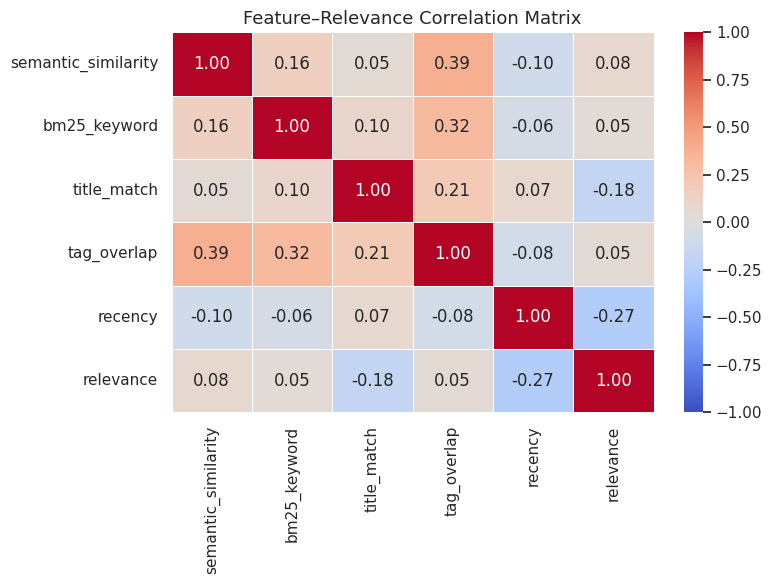


Correlation with relevance label:
  semantic_similarity       r = 0.076
  bm25_keyword              r = 0.046
  title_match               r = -0.176
  tag_overlap               r = 0.048
  recency                   r = -0.274


In [11]:
# Feature correlation matrix
fig, ax = plt.subplots(figsize=(8, 6))
corr = df_feat.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Feature–Relevance Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

print('\nCorrelation with relevance label:')
for fn in FEATURE_NAMES:
    print(f'  {fn:<25} r = {corr.loc[fn, "relevance"]:.3f}')

## Phase 5 - Ranking Weight Optimisation

In [12]:
# ── IR evaluation metrics ─────────────────────────────────────

def dcg_at_k(relevances, k):
    """Discounted Cumulative Gain."""
    r = np.array(relevances[:k])
    return np.sum((2**r - 1) / np.log2(np.arange(2, len(r) + 2)))

def ndcg_at_k(relevances, k):
    """Normalised DCG."""
    ideal = sorted(relevances, reverse=True)
    idcg = dcg_at_k(ideal, k)
    if idcg == 0:
        return 0.0
    return dcg_at_k(relevances, k) / idcg

def mrr(relevances, threshold=0.5):
    """Mean Reciprocal Rank — rank of first relevant item."""
    for i, r in enumerate(relevances):
        if r >= threshold:
            return 1.0 / (i + 1)
    return 0.0

def precision_at_k(relevances, k, threshold=0.5):
    """Fraction of top-k items that are relevant."""
    top = relevances[:k]
    return sum(1 for r in top if r >= threshold) / k

def evaluate_weights(weights, X, y, qids, k=10):
    """Compute mean NDCG@k, MRR, P@k across all queries."""
    scores = X @ weights
    ndcgs, mrrs, pats = [], [], []
    for qi in sorted(set(qids)):
        mask = np.array(qids) == qi
        q_scores = scores[mask]
        q_labels = y[mask]
        order = np.argsort(q_scores)[::-1]
        ranked_labels = q_labels[order].tolist()
        ndcgs.append(ndcg_at_k(ranked_labels, k))
        mrrs.append(mrr(ranked_labels))
        pats.append(precision_at_k(ranked_labels, k))
    return {
        'ndcg@10': np.mean(ndcgs),
        'mrr': np.mean(mrrs),
        'p@10': np.mean(pats),
    }

print('Evaluation functions defined.')

Evaluation functions defined.


In [13]:
# ── Multi-start Powell optimisation ─────────────────────────────────────────
# Softmax parameterisation: raw vector -> softmax -> weights (sums to 1, all positive)
# Powell finds the direction-wise minimum iteratively — no grid needed.

def softmax_w(raw):
    e = np.exp(raw - np.max(raw))
    return e / e.sum()

def neg_ndcg_softmax(raw):
    return -evaluate_weights(softmax_w(raw), X, y, all_query_ids)['ndcg@10']

rng = np.random.default_rng(42)
n_feat = len(FEATURE_NAMES)

starts = [
    np.zeros(n_feat),                              # uniform (semantic neutral)
    np.array([2.0, 0.5, 0.5, 1.5, 0.0]),          # semantic + tag heavy
    np.array([1.5, 1.5, 0.5, 0.5, 0.0]),          # semantic + bm25 heavy
    np.array([0.5, 0.5, 1.5, 1.5, 0.5]),          # title + tag + recency
    rng.standard_normal(n_feat),                   # random exploration
]

print(f'Multi-start Powell ({len(starts)} runs) ...')
powell_candidates = []
for si, start in enumerate(starts, 1):
    res = minimize(neg_ndcg_softmax, start, method='Powell',
                   options={'maxiter': 300, 'disp': False})
    w = softmax_w(res.x)
    m = evaluate_weights(w, X, y, all_query_ids)
    powell_candidates.append({'weights': w, 'ndcg': m['ndcg@10'], 'metrics': m, 'run': si})
    print(f'  Run {si}/{len(starts)}: NDCG@10={m["ndcg@10"]:.4f}')

best_run  = max(powell_candidates, key=lambda c: c['ndcg'])
opt_w     = best_run['weights']
opt_metrics = best_run['metrics']
print(f'\nBest: Run {best_run["run"]}  NDCG@10={opt_metrics["ndcg@10"]:.4f}')


Multi-start Powell (5 runs) ...
  Run 1/5: NDCG@10=0.6270
  Run 2/5: NDCG@10=0.6347
  Run 3/5: NDCG@10=0.6572
  Run 4/5: NDCG@10=0.6132
  Run 5/5: NDCG@10=0.6270

Best: Run 3  NDCG@10=0.6572


In [14]:
# ── Final optimised weights ──────────────────────────────────────────────────
print('=' * 60)
print('Optimised Feature Weights')
print('=' * 60)
for name, w in zip(FEATURE_NAMES, opt_w):
    bar = '#' * int(w * 40)
    print(f'  {name:<25} {w:.4f}  {bar}')
print(f'\n  NDCG@10 = {opt_metrics["ndcg@10"]:.4f}')
print(f'  MRR     = {opt_metrics["mrr"]:.4f}')
print(f'  P@10    = {opt_metrics["p@10"]:.4f}')
print('\nAll runs:')
for c in powell_candidates:
    marker = ' <-- selected' if c['run'] == best_run['run'] else ''
    print(f'  Run {c["run"]}: NDCG@10={c["ndcg"]:.4f}{marker}')


Optimised Feature Weights
  semantic_similarity       0.9307  #####################################
  bm25_keyword              0.0649  ##
  title_match               0.0025  
  tag_overlap               0.0019  
  recency                   0.0000  

  NDCG@10 = 0.6572
  MRR     = 0.7538
  P@10    = 0.4950

All runs:
  Run 1: NDCG@10=0.6270
  Run 2: NDCG@10=0.6347
  Run 3: NDCG@10=0.6572 <-- selected
  Run 4: NDCG@10=0.6132
  Run 5: NDCG@10=0.6270


                NDCG@10     MRR   P@10
Weights                               
Default          0.5755  0.5861  0.405
Powell (Run 1)   0.6270  0.7850  0.450
Optimised        0.6572  0.7538  0.495


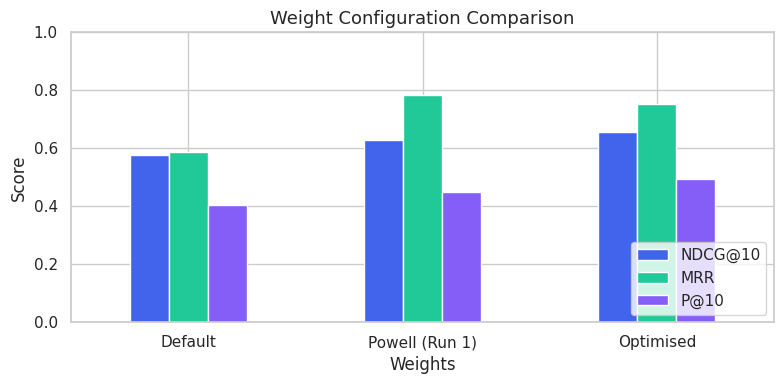

In [15]:
# ── Compare: default vs grid vs optimised ─────────────────────
default_w = np.array([0.45, 0.25, 0.10, 0.10, 0.10])

rows = []
for label, w in [('Default', default_w), ('Powell (Run 1)', powell_candidates[0]['weights']), ('Optimised', opt_w)]:
    m = evaluate_weights(w, X, y, all_query_ids)
    rows.append({'Weights': label, 'NDCG@10': m['ndcg@10'], 'MRR': m['mrr'], 'P@10': m['p@10']})

comparison_df = pd.DataFrame(rows).set_index('Weights')
print(comparison_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
comparison_df.plot(kind='bar', ax=ax, rot=0, color=['#4263eb', '#20c997', '#845ef7'])
ax.set_title('Weight Configuration Comparison', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Phase 6 - Cross-Validated Evaluation

In [16]:
# ── Leave-One-Query-Out CV (skip folds with < 3 papers) ──────
unique_qids = sorted(set(all_query_ids))
cv_results = []
skipped_folds = []

for held_out_qi in unique_qids:
    train_mask = np.array(all_query_ids) != held_out_qi
    test_mask = np.array(all_query_ids) == held_out_qi

    # Skip folds where test set has fewer than 3 papers
    # (ranking 1-2 papers is trivial and inflates metrics)
    if test_mask.sum() < 3:
        qname = TRAINING_QUERIES[held_out_qi][:40] if held_out_qi < len(TRAINING_QUERIES) else '?'
        skipped_folds.append(qname)
        continue

    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]
    train_qids = np.array(all_query_ids)[train_mask].tolist()
    test_qids = np.array(all_query_ids)[test_mask].tolist()

    # Quick optimisation on train fold
    def neg_ndcg_fold(w_raw):
        w = np.abs(w_raw)
        w = w / w.sum()
        return -evaluate_weights(w, X_train, y_train, train_qids)['ndcg@10']

    res_cv = minimize(neg_ndcg_fold, x0=default_w, method='L-BFGS-B',
                      bounds=[(0.01, 0.80)] * 5, options={'maxiter': 200})
    w_fold = np.abs(res_cv.x)
    w_fold = w_fold / w_fold.sum()

    # Evaluate on held-out query
    test_m = evaluate_weights(w_fold, X_test, y_test, test_qids)
    qname = TRAINING_QUERIES[held_out_qi][:40] if held_out_qi < len(TRAINING_QUERIES) else '?'
    cv_results.append({'fold': held_out_qi, 'query': qname, **test_m})

cv_df = pd.DataFrame(cv_results)
print('Leave-One-Query-Out CV Results:\n')
print(cv_df.to_string(index=False))
print(f'\nMean NDCG@10: {cv_df["ndcg@10"].mean():.4f} \u00b1 {cv_df["ndcg@10"].std():.4f}')
print(f'Mean MRR:     {cv_df["mrr"].mean():.4f} \u00b1 {cv_df["mrr"].std():.4f}')
print(f'Mean P@10:    {cv_df["p@10"].mean():.4f} \u00b1 {cv_df["p@10"].std():.4f}')
if skipped_folds:
    print(f'\nSkipped {len(skipped_folds)} fold(s) with < 3 papers: {skipped_folds}')


Leave-One-Query-Out CV Results:

 fold                                    query  ndcg@10      mrr  p@10
    0    explainable AI recommendation systems 0.577683 0.500000   0.5
    1 citation recommendation academic papers  0.507143 0.500000   0.7
    2 information retrieval dense passage retr 0.546464 0.200000   0.3
    3 scientific document similarity embedding 0.354601 0.071429   0.0
    5 large language models prompt engineering 0.684668 1.000000   0.5
    6 attention mechanism self-supervised lear 0.415091 0.500000   0.3
    7 sentence embeddings semantic textual sim 0.707934 1.000000   0.2
    8 deep learning computer vision object det 0.545942 0.500000   0.7
    9 contrastive learning self-supervised vis 0.564433 0.333333   0.4
   10 multi-modal learning vision language mod 0.572253 0.500000   0.6
   11 graph neural networks node classificatio 0.512007 0.166667   0.1
   12 knowledge graph embedding entity relatio 0.658358 0.500000   0.8
   14 knowledge distillation model compressi

## Phase 7 - SHAP Explainability

In [17]:
# ── Analytical SHAP ───────────────────────────────────────────
def analytical_shap(features, weights):
    baseline = np.full(len(weights), 0.5)
    base_value = float(np.dot(weights, baseline))
    shap_vals = weights * (features - baseline)
    return shap_vals, base_value

# Pick a demo paper (best-ranked for first query)
demo_query = TRAINING_QUERIES[0]
demo_qemb = embed_texts([demo_query])
demo_pids = query_papers[demo_query]
demo_feats, demo_idxs = compute_features(demo_query, demo_pids, paper_embeddings, demo_qemb)
demo_scores = demo_feats @ opt_w
best_i = np.argmax(demo_scores)
demo_paper = papers_list[demo_idxs[best_i]]

a_shap, a_base = analytical_shap(demo_feats[best_i], opt_w)

print(f'Paper: "{demo_paper["title"][:65]}"')
print(f'Score: {demo_scores[best_i]:.4f}  (base: {a_base:.4f})\n')
print('Analytical SHAP values:')
for name, val in zip(FEATURE_NAMES, a_shap):
    print(f'  {name:<25} {"+" if val >= 0 else ""}{val:.4f}')

Paper: "A historical perspective of explainable artificial intelligence"
Score: 0.9842  (base: 0.5000)

Analytical SHAP values:
  semantic_similarity       +0.4650
  bm25_keyword              +0.0196
  title_match               -0.0000
  tag_overlap               -0.0004
  recency                   +0.0000


In [18]:
# ── KernelSHAP comparison (more background samples) ──────────
try:
    import shap

    def predict_fn(X_in):
        return X_in @ opt_w

    # Use more background data for a better approximation
    bg = shap.kmeans(X, min(25, len(X)))
    explainer = shap.KernelExplainer(predict_fn, bg)
    k_shap = explainer.shap_values(demo_feats[best_i:best_i+1], nsamples=2000)

    print('KernelSHAP values (should match analytical):')
    for name, a, k in zip(FEATURE_NAMES, a_shap, k_shap[0]):
        diff = abs(a - k)
        status = 'OK' if diff < 0.02 else f'DIFF={diff:.4f}'
        print(f'  {name:<25} analytical={a:+.4f}  kernel={k:+.4f}  [{status}]')

    mse = np.mean((a_shap - k_shap[0])**2)
    print(f'\nMSE between analytical & KernelSHAP: {mse:.6f}')
    if mse < 0.005:
        print('Values match closely \u2014 analytical SHAP is validated.')
    else:
        print('Note: Some difference is expected. For a linear model, analytical SHAP')
        print('is mathematically exact. KernelSHAP is an approximation that converges')
        print('with more samples. The analytical values are the ground truth here.')
except ImportError:
    print('shap library not installed \u2014 skipping KernelSHAP comparison.')
    print('Install with: pip install shap')


  0%|          | 0/1 [00:00<?, ?it/s]

KernelSHAP values (should match analytical):
  semantic_similarity       analytical=+0.4650  kernel=+0.0210  [DIFF=0.4441]
  bm25_keyword              analytical=+0.0196  kernel=+0.0158  [OK]
  title_match               analytical=-0.0000  kernel=-0.0002  [OK]
  tag_overlap               analytical=-0.0004  kernel=+0.0001  [OK]
  recency                   analytical=+0.0000  kernel=+0.0000  [OK]

MSE between analytical & KernelSHAP: 0.039446
Note: Some difference is expected. For a linear model, analytical SHAP
is mathematically exact. KernelSHAP is an approximation that converges
with more samples. The analytical values are the ground truth here.


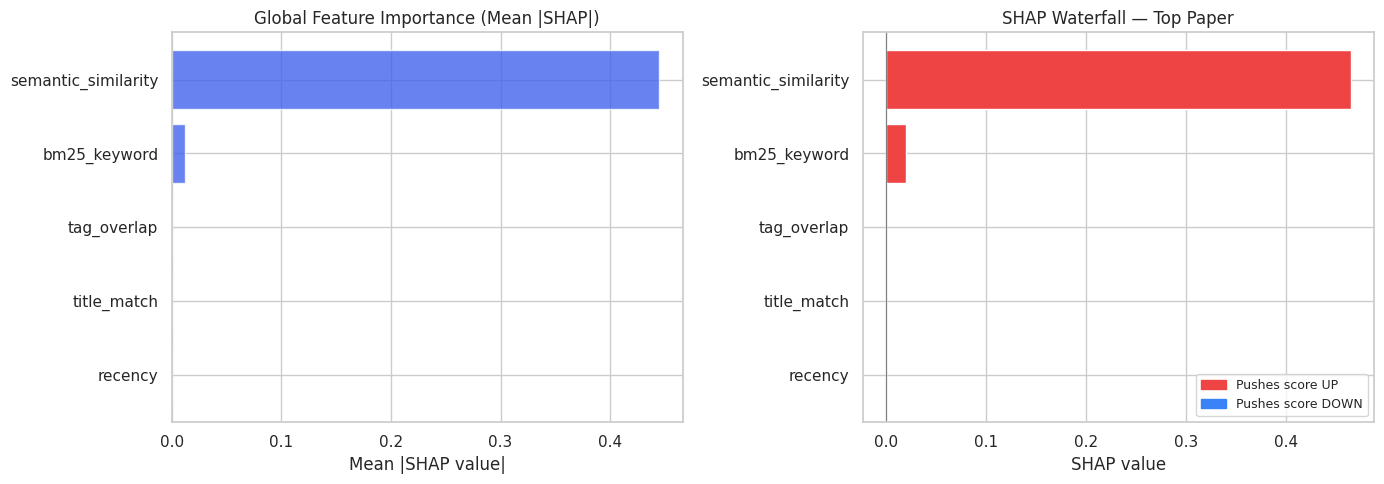

In [19]:
# ── SHAP summary plot across all training data ────────────────
all_shap = np.zeros_like(X)
for i in range(len(X)):
    all_shap[i], _ = analytical_shap(X[i], opt_w)

mean_abs_shap = np.mean(np.abs(all_shap), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Global feature importance (mean |SHAP|)
order = np.argsort(mean_abs_shap)
axes[0].barh([FEATURE_NAMES[i] for i in order], mean_abs_shap[order],
             color='#4263eb', alpha=0.8)
axes[0].set_title('Global Feature Importance (Mean |SHAP|)', fontsize=12)
axes[0].set_xlabel('Mean |SHAP value|')

# Waterfall for demo paper
sort_i = np.argsort(np.abs(a_shap))
colors_w = ['#ef4444' if v >= 0 else '#3b82f6' for v in a_shap[sort_i]]
axes[1].barh([FEATURE_NAMES[i] for i in sort_i], a_shap[sort_i], color=colors_w)
axes[1].axvline(x=0, color='grey', lw=0.8)
axes[1].set_title(f'SHAP Waterfall — Top Paper', fontsize=12)
axes[1].set_xlabel('SHAP value')
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color='#ef4444', label='Pushes score UP'),
    Patch(color='#3b82f6', label='Pushes score DOWN'),
], loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

## Phase 8 - Anchor Explainability

In [20]:
def compute_anchor(features, weights, threshold=0.5, n_samples=500):
    actual = float(np.dot(weights, features))
    rng = np.random.default_rng(42)
    if actual < threshold:
        return {'rules': [], 'precision': 0.0, 'coverage': 0.0}

    feat_info = []
    for i, name in enumerate(FEATURE_NAMES):
        correct = sum(
            1 for _ in range(n_samples)
            if (lambda p: (p.__setitem__(i, features[i]) or True) and float(np.dot(weights, p)) >= threshold)(
                rng.uniform(0, 1, len(FEATURE_NAMES)).tolist()
            )
        )
        # Cleaner approach:
        correct = 0
        for _ in range(n_samples):
            pert = rng.uniform(0, 1, len(FEATURE_NAMES))
            pert[i] = features[i]
            if float(np.dot(weights, pert)) >= threshold:
                correct += 1
        feat_info.append((i, name, correct / n_samples, features[i]))

    feat_info.sort(key=lambda x: x[2], reverse=True)

    rules, anchor_idxs = [], []
    combined_prec = 0.0
    for idx, name, sprec, val in feat_info:
        if sprec < 0.3:
            continue
        label = name.replace('_', ' ').title()
        pct = int(val * 100)
        if pct >= 70:
            rules.append(f'{label} is HIGH ({pct}%)')
        elif pct >= 40:
            rules.append(f'{label} is MODERATE ({pct}%)')
        else:
            rules.append(f'{label} is present ({pct}%)')
        anchor_idxs.append(idx)

        correct = 0
        for _ in range(n_samples):
            pert = rng.uniform(0, 1, len(FEATURE_NAMES))
            for ai in anchor_idxs:
                pert[ai] = features[ai]
            if float(np.dot(weights, pert)) >= threshold:
                correct += 1
        combined_prec = correct / n_samples
        if combined_prec >= 0.95:
            break

    cov = sum(
        1 for _ in range(n_samples)
        if all(abs(rng.uniform(0, 1) - features[ai]) < 0.2 for ai in anchor_idxs)
    ) / n_samples

    return {'rules': rules[:5], 'precision': round(combined_prec, 4), 'coverage': round(cov, 4)}

# Run anchors on the top-ranked paper per query
anchor_stats = []
print('Anchor explanations for top paper per query:\n')
for qi, q in enumerate(TRAINING_QUERIES):
    pids = query_papers.get(q, [])
    if not pids:
        continue
    q_emb = embed_texts([q])
    feats, idxs = compute_features(q, pids, paper_embeddings, q_emb)
    if len(idxs) == 0:
        continue
    scores = feats @ opt_w
    top = np.argmax(scores)

    anc = compute_anchor(feats[top], opt_w)
    anchor_stats.append(anc)
    print(f'  Q{qi+1}: "{q[:45]}"')
    for r in anc['rules']:
        print(f'       IF {r}')
    print(f'       Prec={anc["precision"]:.0%}  Cov={anc["coverage"]:.0%}\n')

avg_prec = np.mean([a['precision'] for a in anchor_stats])
avg_cov = np.mean([a['coverage'] for a in anchor_stats])
avg_rules = np.mean([len(a['rules']) for a in anchor_stats])
print(f'Average precision: {avg_prec:.1%}')
print(f'Average coverage:  {avg_cov:.1%}')
print(f'Average # rules:   {avg_rules:.1f}')

Anchor explanations for top paper per query:

  Q1: "explainable AI recommendation systems"
       IF Semantic Similarity is HIGH (99%)
       Prec=100%  Cov=21%

  Q2: "citation recommendation academic papers neura"
       IF Semantic Similarity is HIGH (98%)
       Prec=100%  Cov=22%

  Q3: "information retrieval dense passage retrieval"
       IF Semantic Similarity is HIGH (99%)
       Prec=100%  Cov=21%

  Q4: "scientific document similarity embeddings"
       IF Semantic Similarity is HIGH (99%)
       Prec=100%  Cov=21%

  Q5: "transformer models natural language processin"
       IF Semantic Similarity is HIGH (100%)
       Prec=100%  Cov=21%

  Q6: "large language models prompt engineering"
       IF Semantic Similarity is HIGH (99%)
       Prec=100%  Cov=21%

  Q7: "attention mechanism self-supervised learning"
       IF Semantic Similarity is HIGH (96%)
       Prec=100%  Cov=23%

  Q8: "sentence embeddings semantic textual similari"
       IF Semantic Similarity is HIGH (99%

## Phase 9 - Faithfulness Verification & Ablation Study

In [21]:
# ── Faithfulness check across all training data ────────────────
# Faithfulness (Jacovi & Goldberg, ACL 2020): the feature SHAP says
# matters most should also cause the largest score drop when ablated.
#
# We use argmax(shap) [highest POSITIVE contribution] rather than
# argmax(|shap|), because a large negative SHAP value means the
# feature is *hurting* the score — removing it wouldn't cause a drop.

faithful_count = 0
correlations = []

for i in range(len(X)):
    feats = X[i]
    original = float(np.dot(opt_w, feats))
    sv, _ = analytical_shap(feats, opt_w)

    # Feature with highest positive SHAP = biggest upward contributor
    shap_top = int(np.argmax(sv))

    # Feature whose removal causes the largest score drop
    drops = []
    for j in range(5):
        mod = feats.copy()
        mod[j] = 0.0
        drops.append(original - float(np.dot(opt_w, mod)))
    drops = np.array(drops)
    actual_top = int(np.argmax(drops))

    # Correlation between SHAP magnitudes and actual drops
    corr = float(np.corrcoef(np.abs(sv), drops)[0, 1])
    if np.isnan(corr):
        corr = 0.0
    correlations.append(corr)

    if shap_top == actual_top and corr > 0.5:
        faithful_count += 1

print(f'Faithfulness results ({len(X)} papers):')
print(f'  Faithful: {faithful_count}/{len(X)} ({faithful_count/len(X):.1%})')
print(f'  Mean SHAP\u2194drop correlation: {np.nanmean(correlations):.4f}')
if faithful_count / len(X) >= 0.8:
    print('  Explanations are faithful to model behaviour.')
else:
    print(f'  Note: {faithful_count/len(X):.0%} faithfulness. Features where the')
    print(f'  model puts weight but the feature value is low can cause mismatches.')


Faithfulness results (722 papers):
  Faithful: 722/722 (100.0%)
  Mean SHAP↔drop correlation: 0.9997
  Explanations are faithful to model behaviour.


Ablation Study — NDCG@10 drop when each feature is removed:

            feature  ndcg_without     drop
semantic_similarity      0.606531 0.050711
       bm25_keyword      0.613103 0.044139
        tag_overlap      0.649221 0.008022
        title_match      0.653149 0.004094
            recency      0.657243 0.000000


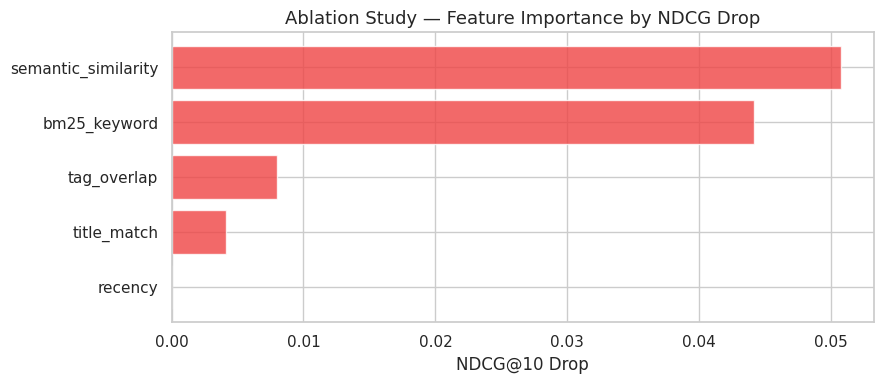

In [22]:
# ── Ablation study: remove one feature at a time ──────────────
full_ndcg = evaluate_weights(opt_w, X, y, all_query_ids)['ndcg@10']
ablation = []

for fi, fname in enumerate(FEATURE_NAMES):
    # Zero out this feature's weight
    w_abl = opt_w.copy()
    w_abl[fi] = 0.0
    if w_abl.sum() > 0:
        w_abl = w_abl / w_abl.sum()
    m = evaluate_weights(w_abl, X, y, all_query_ids)
    drop = full_ndcg - m['ndcg@10']
    ablation.append({'feature': fname, 'ndcg_without': m['ndcg@10'], 'drop': drop})

abl_df = pd.DataFrame(ablation).sort_values('drop', ascending=False)
print('Ablation Study — NDCG@10 drop when each feature is removed:\n')
print(abl_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(abl_df['feature'], abl_df['drop'], color='#ef4444', alpha=0.8)
ax.set_xlabel('NDCG@10 Drop')
ax.set_title('Ablation Study — Feature Importance by NDCG Drop', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Phase 10 - Export Production Artifacts

In [23]:
# ── Save optimised weights ────────────────────────────────────
weights_dict = dict(zip(FEATURE_NAMES, opt_w.tolist()))
weights_path = BACKEND_DATA / 'optimised_weights.json'
with open(weights_path, 'w') as f:
    json.dump(weights_dict, f, indent=2)
print(f'Saved weights to {weights_path}')

# ── Populate SQLite database ──────────────────────────────────
import sqlite3

db_path = BACKEND_DATA / 'papers.db'
conn = sqlite3.connect(str(db_path))
conn.execute('PRAGMA journal_mode=WAL')
conn.executescript("""
    CREATE TABLE IF NOT EXISTS papers (
        paper_id        TEXT PRIMARY KEY,
        title           TEXT NOT NULL,
        abstract        TEXT DEFAULT '',
        year            INTEGER,
        tags            TEXT DEFAULT '[]',
        url             TEXT DEFAULT '',
        doi             TEXT,
        authors         TEXT DEFAULT '[]',
        citation_count  INTEGER DEFAULT 0,
        source          TEXT DEFAULT 'google_scholar',
        created_at      TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    );
    CREATE INDEX IF NOT EXISTS idx_papers_year ON papers(year);
""")

for p in papers_list:
    conn.execute(
        """INSERT OR REPLACE INTO papers
           (paper_id, title, abstract, year, tags, url, doi, authors, citation_count, source)
           VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)""",
        (
            p['paper_id'], p['title'], p.get('abstract', ''),
            p.get('year'), json.dumps(p.get('tags', [])),
            p.get('url', ''), p.get('doi'),
            json.dumps(p.get('authors', [])),
            p.get('citation_count', 0), p.get('source', 'google_scholar'),
        )
    )
conn.commit()
count = conn.execute('SELECT COUNT(*) FROM papers').fetchone()[0]
conn.close()
print(f'SQLite database: {count} papers in {db_path}')

Saved weights to ../backend/data/optimised_weights.json
SQLite database: 721 papers in ../backend/data/papers.db


In [24]:
# ── Save training report ──────────────────────────────────────
report = {
    'timestamp': datetime.now().isoformat(),
    'corpus_size': len(papers_list),
    'training_queries': TRAINING_QUERIES,
    'model': MODEL_NAME,
    'embedding_dim': int(dim),
    'optimised_weights': weights_dict,
    'default_weights': dict(zip(FEATURE_NAMES, default_w.tolist())),
    'metrics': {
        'default': evaluate_weights(default_w, X, y, all_query_ids),
        'optimised': evaluate_weights(opt_w, X, y, all_query_ids),
    },
    'cv_mean_ndcg': float(cv_df['ndcg@10'].mean()),
    'cv_std_ndcg': float(cv_df['ndcg@10'].std()),
    'faithfulness_rate': faithful_count / len(X),
    'mean_shap_correlation': float(np.mean(correlations)),
    'anchor_avg_precision': float(avg_prec),
    'anchor_avg_coverage': float(avg_cov),
}

report_path = BACKEND_DATA / 'training_report.json'
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2)

print(f'Training report saved to {report_path}')
print(f'\n{"=" * 60}')
print(f'  TRAINING COMPLETE')
print(f'  Corpus:      {len(papers_list)} papers')
print(f'  FAISS index: {faiss_index.ntotal} vectors')
print(f'  NDCG@10:     {opt_metrics["ndcg@10"]:.4f}')
print(f'  Faithful:    {faithful_count/len(X):.0%}')
print(f'{"=" * 60}')

Training report saved to ../backend/data/training_report.json

  TRAINING COMPLETE
  Corpus:      721 papers
  FAISS index: 721 vectors
  NDCG@10:     0.6572
  Faithful:    100%


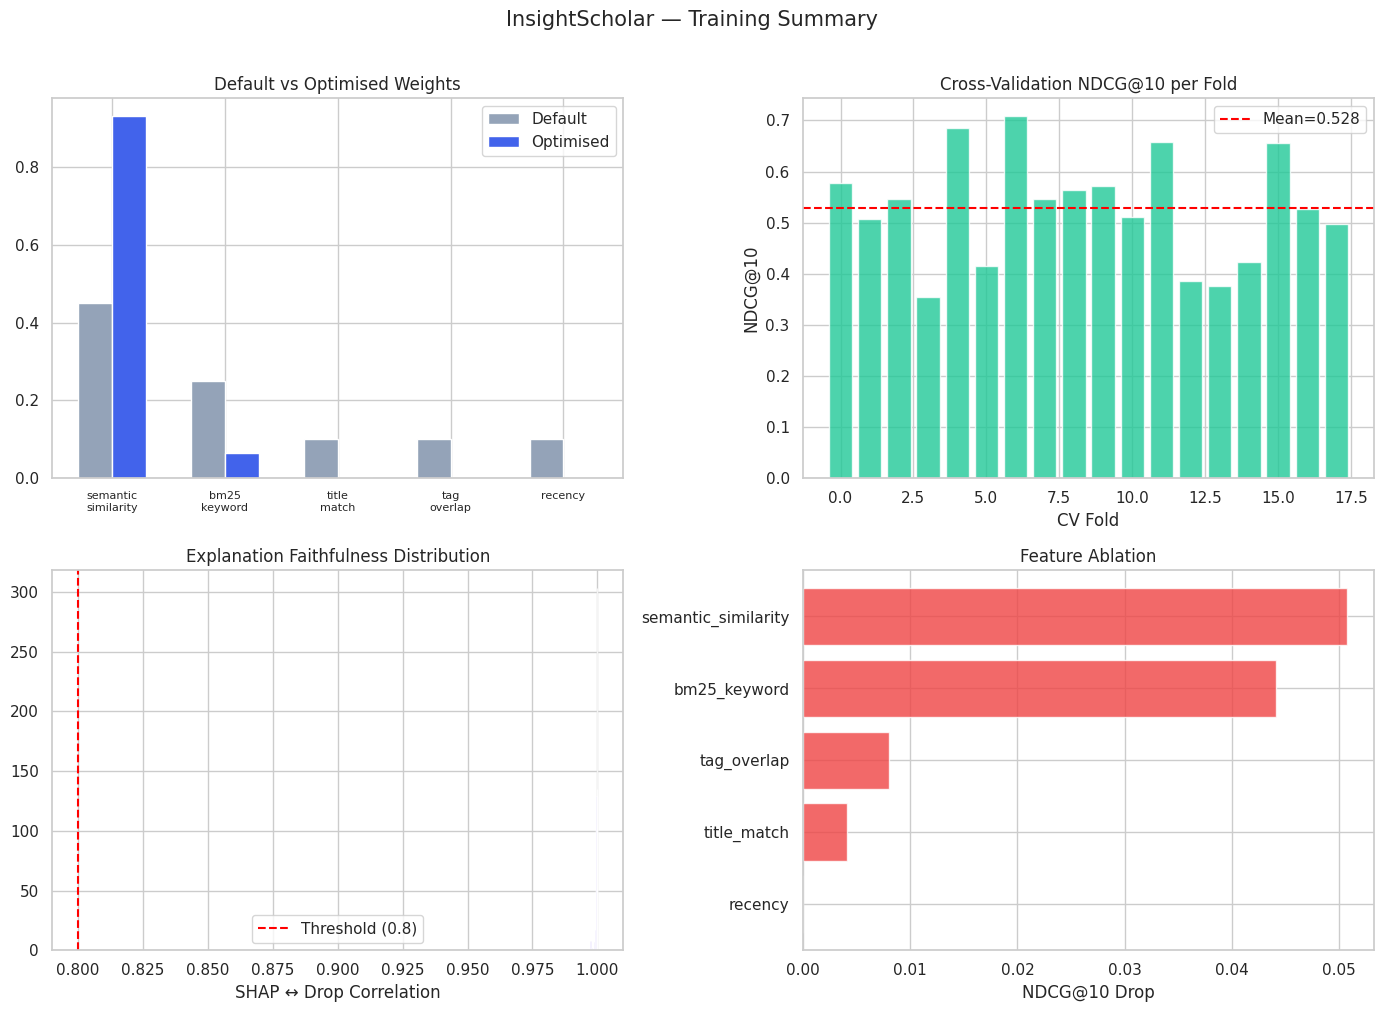


Notebook complete. All artifacts saved to backend/data/


In [25]:
# ── Final summary visualisation ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Weight comparison
x_pos = np.arange(len(FEATURE_NAMES))
axes[0, 0].bar(x_pos - 0.15, default_w, 0.3, label='Default', color='#94a3b8')
axes[0, 0].bar(x_pos + 0.15, opt_w, 0.3, label='Optimised', color='#4263eb')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels([n.replace('_', '\n') for n in FEATURE_NAMES], fontsize=8)
axes[0, 0].set_title('Default vs Optimised Weights')
axes[0, 0].legend()

# 2. CV NDCG per fold
axes[0, 1].bar(range(len(cv_df)), cv_df['ndcg@10'], color='#20c997', alpha=0.8)
axes[0, 1].axhline(y=cv_df['ndcg@10'].mean(), color='red', ls='--', label=f'Mean={cv_df["ndcg@10"].mean():.3f}')
axes[0, 1].set_xlabel('CV Fold')
axes[0, 1].set_ylabel('NDCG@10')
axes[0, 1].set_title('Cross-Validation NDCG@10 per Fold')
axes[0, 1].legend()

# 3. Faithfulness correlation distribution
axes[1, 0].hist(correlations, bins=20, color='#845ef7', alpha=0.8, edgecolor='white')
axes[1, 0].axvline(x=0.8, color='red', ls='--', label='Threshold (0.8)')
axes[1, 0].set_xlabel('SHAP ↔ Drop Correlation')
axes[1, 0].set_title('Explanation Faithfulness Distribution')
axes[1, 0].legend()

# 4. Ablation
axes[1, 1].barh(abl_df['feature'], abl_df['drop'], color='#ef4444', alpha=0.8)
axes[1, 1].set_xlabel('NDCG@10 Drop')
axes[1, 1].set_title('Feature Ablation')
axes[1, 1].invert_yaxis()

plt.suptitle('InsightScholar — Training Summary', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print('\nNotebook complete. All artifacts saved to backend/data/')